# Preprocessing check

Runs `build_pipeline()` end to end and visually confirms it did what `docs/superpowers/specs/2026-09-04-preprocessing-feature-engineering-design.md` claims -- not new analysis, a verification pass, matching the EDA series' habit of checking a transform rather than trusting it.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ames_price.constants import NOMINAL_COLS, NUMERIC_COLS, ORDINAL_COLS
from ames_price.pipeline import build_pipeline

FEATURE_COLS = NUMERIC_COLS + ORDINAL_COLS + NOMINAL_COLS

In [2]:
df_train = pd.read_csv("../data/train.csv")
df_test = pd.read_csv("../data/test.csv")

# per the design doc: drop the two flagged outliers before fitting
# anything, so no imputation/bucketing statistic is influenced by them
df_train = df_train[~df_train["Id"].isin([524, 1299])]
df_train.shape, df_test.shape

((1458, 81), (1459, 80))

In [3]:
pipeline = build_pipeline()
train_out = pipeline.fit_transform(df_train[FEATURE_COLS])
test_out = pipeline.transform(df_test[FEATURE_COLS])

assert not train_out.isna().any().any()
assert not test_out.isna().any().any()
train_out.shape, test_out.shape

((1458, 237), (1459, 237))

## Column-set sanity check

Confirm the identity columns are gone and the new derived/flag columns are present.

In [4]:
for col in ["1stFlrSF", "BsmtUnfSF", "Utilities"]:
    assert col not in train_out.columns, col
for col in ["HasGarage", "GarageAge", "HasOpenPorchSF", "HasPoolArea"]:
    assert col in train_out.columns, col
print("ok")

ok


## Log-transform check

Before/after histograms for a couple of the flagged skewed columns -- confirming the skew reduction shows up here, not just in `1_target_variable.ipynb`.

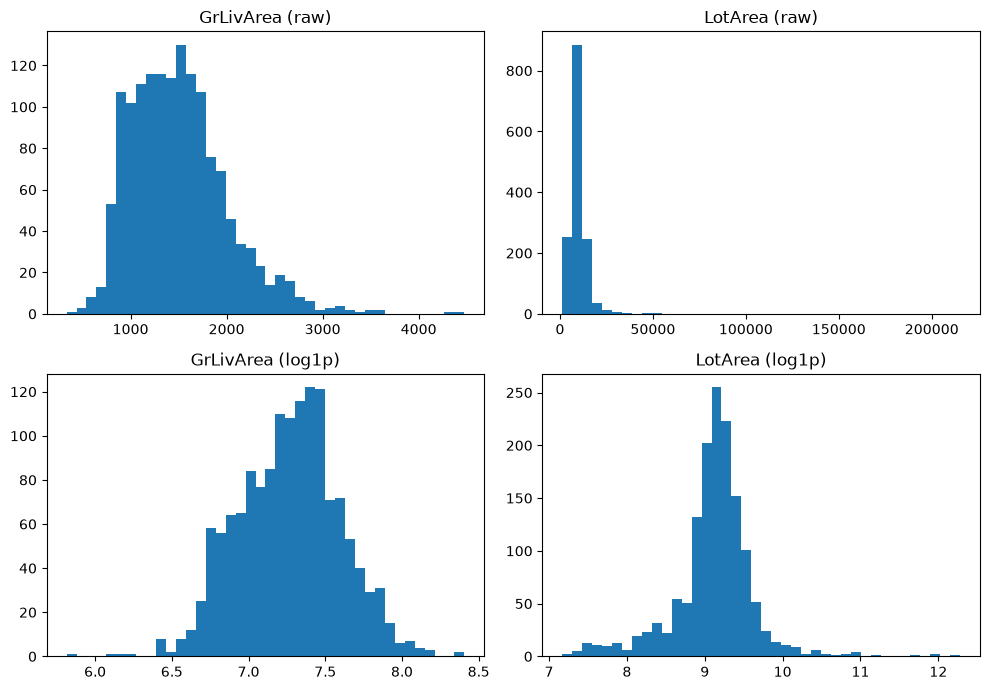

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
sns_cols = ["GrLivArea", "LotArea"]
for i, col in enumerate(sns_cols):
    axes[0, i].hist(df_train[col].dropna(), bins=40)
    axes[0, i].set_title(f"{col} (raw)")
    axes[1, i].hist(train_out[col], bins=40)
    axes[1, i].set_title(f"{col} (log1p)")
plt.tight_layout()
plt.show()

## Bucketing check

Every fitted ordinal merge map (all 8 `_ORDINAL_BUCKET_COLS`), not just
a hand-picked pair -- a prior review round only spot-checked
`ExterCond`/`RoofMatl`, which is why `PoolQC` collapsing into a
constant column went unnoticed until the whole-branch review. Followed
by the nominal bucket check and a near-zero-variance scan of the full
output.

In [6]:
engineer = pipeline.named_steps["engineer"]
for col, merge_map in engineer.ordinal_merge_maps_.items():
    print(f"{col}: {merge_map}")

ExterCond: {'Po': 'Fa', 'Fa': 'Fa', 'TA': 'TA', 'Gd': 'Gd', 'Ex': 'Gd'}
Functional: {'Sal': 'Maj1', 'Sev': 'Maj1', 'Maj2': 'Maj1', 'Maj1': 'Maj1', 'Mod': 'Mod', 'Min2': 'Min2', 'Min1': 'Min1', 'Typ': 'Typ'}
HeatingQC: {'Po': 'Fa', 'Fa': 'Fa', 'TA': 'TA', 'Gd': 'Gd', 'Ex': 'Ex'}
BsmtCond: {'Po': 'Fa', 'Fa': 'Fa', 'TA': 'TA', 'Gd': 'Gd', 'Ex': 'Gd', 'None': 'None'}
GarageCond: {'Po': 'Fa', 'Fa': 'Fa', 'TA': 'TA', 'Gd': 'Gd', 'Ex': 'Gd', 'None': 'None'}
OverallQual: {1: 3, 2: 3, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10}
PoolQC: {'Fa': 'Gd', 'TA': 'Gd', 'Gd': 'Gd', 'Ex': 'Gd', 'None': 'None'}
GarageQual: {'Po': 'Fa', 'Fa': 'Fa', 'TA': 'TA', 'Gd': 'Gd', 'Ex': 'Gd', 'None': 'None'}


In [7]:
roofmatl_cols = [c for c in train_out.columns if c.startswith("RoofMatl_")]
print(train_out[roofmatl_cols].sum())

RoofMatl_CompShg    1433.0
RoofMatl_Other        25.0
dtype: float64


In [8]:
# A constant (or near-constant) output column carries zero predictive
# information, and for a bucketed ordinal it's a red flag: it's exactly
# what "None" absorbing every real rating (PoolQC, pre-fix) looked
# like, so this check exists to catch that class of bug directly
# rather than relying on a human noticing a suspiciously short
# value_counts print.
constant_cols = train_out.columns[train_out.nunique() <= 1]
print("Near-zero-variance columns:", list(constant_cols))

print()
print("PoolQC (post-Encoder, integer-coded):")
print(train_out["PoolQC"].value_counts().sort_index())

Near-zero-variance columns: []

PoolQC (post-Encoder, integer-coded):
PoolQC
0    1452
3       6
Name: count, dtype: int64


## Derived-feature spot check

`GarageAge` should be exactly 0 wherever `HasGarage` is `False`.

In [9]:
no_garage = train_out["HasGarage"] == 0
assert (train_out.loc[no_garage, "GarageAge"] == 0).all()
print(f"{no_garage.sum()} no-garage rows, all GarageAge == 0")

81 no-garage rows, all GarageAge == 0
